# Universidad Libre - Seccional Cali<br>Facultad de Ingeniería - Diplomado en Ciencia de Datos<br>(ↄ) Juan Sebastian Diaz Campos, 2026

# 03_EDA
Plantilla para el desarrollo del proyecto del diplomado de Ciencia de Datos, aplicando buenas prácticas.

---

Este cuaderno se centra en comprender profundamente los datos mediante análisis estadístico y visualización. El EDA nos permite descubrir patrones, relaciones y características importantes en los datos.

**Propósito:** Obtener insights sobre los datos y preparar el terreno para la selección de características relevantes para el modelado.

**Tareas habituales:**
- Análisis univariante de variables
- Análisis de correlaciones
- Visualización de distribuciones
- Detección de patrones y tendencias
- Análisis de series temporales si aplica
- Identificación de relaciones entre variables
- Generación de hipótesis
- Documentación de insights importantes

**Cada sección debe tener**:
- La Pregunta que se realiza sobre los datos
- El código que genera las tablas o los gráficos donde encontramos la respuesta
- El código que da respuesta a dicha pregunta
- La interpretar del resultado
- Las conclusiones

In [52]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr

In [53]:
cwd = os.getcwd() # current working directory
trusted_dir = cwd + '/../data/trusted/'

In [54]:
df = pd.read_csv(trusted_dir + 'datos_limpios.csv')

In [55]:
df

,ID_caso,Fecha_apertura,Fecha_cierre,Prioridad,Estado,Titulo_caso,Responsable_atencion,Aplicacion,Sitio,Tipo_solicitud_1,...,Nro_dia_cierre,Mes_apertura,Mes_cierre,Hora_apertura,Hora_cierre,Año_caso,ANS_dias_laborales,Apertura_fuera_horario,Cierre_fuera_horario,Cumple_ANS
0,RF699325,2025-04-29 10:24:20,2025-05-02 11:58:20,4 - Baja,Cerrado,Desbloqueo de aplicativo,JSDIAZ,FIRST VISION,EDIFICIO PRINCIPAL,DESBLOQUEO,...,2,4,5,10,11,2025,2,NO,NO,SI
1,RF699520,2025-04-29 12:33:42,2025-05-02 09:18:45,4 - Baja,Cerrado,ASIGNACION DE CLAVE MAILPOINT,JSDIAZ,MAILPOINT,EDIFICIO PRINCIPAL,DESBLOQUEO,...,2,4,5,12,9,2025,2,NO,NO,SI
2,RF699819,2025-04-29 16:53:16,2025-05-06 14:49:45,4 - Baja,Cerrado,Solicitud de creación de usuario FirstData - F...,JSDIAZ,FIRST VISION,EDIFICIO PRINCIPAL,CREACION,...,6,4,5,16,14,2025,4,NO,NO,NO
3,RF700695,2025-05-02 08:56:25,2025-05-05 08:40:49,4 - Baja,Cerrado,DESBLOQUEO ACCESO,JSDIAZ,FIRST VISION,EDIFICIO PRINCIPAL,DESBLOQUEO,...,5,5,5,8,8,2025,1,NO,NO,SI
4,RF700696,2025-05-02 08:56:28,2025-05-02 11:54:47,4 - Baja,Cerrado,DESBLOQUEO APLICATIVO FD - UGR,JSDIAZ,FIRST VISION,EDIFICIO PRINCIPAL,DESBLOQUEO,...,2,5,5,8,11,2025,0,NO,NO,SI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5879,RF872307,2026-05-26 09:32:41,2026-05-26 16:21:16,4 - Baja,Cerrado,DESBLOQUEAR USUARIO DE SWIFT 00951,MRODRIGUEZPE,SWIFT,EDIFICIO PRINCIPAL,DESBLOQUEO,...,26,5,5,9,16,2026,0,NO,NO,SI
5880,RF878267,2026-06-09 18:08:52,2026-06-17 11:35:34,4 - Baja,Cerrado,DOCIT - DESBLOQUEAR USUARIO SWIFT,IAVILA,SWIFT,EDIFICIO PRINCIPAL,DESBLOQUEO,...,17,6,6,18,11,2026,5,SI,NO,NO
5881,RF878819,2026-06-10 16:01:26,2026-07-07 12:35:17,4 - Baja,Cerrado,Modificacion de perfil,MRODRIGUEZPE,SWIFT,EDIFICIO PRINCIPAL,MODIFICACION,...,7,6,7,16,12,2026,17,NO,NO,NO
5882,RF878901,2026-06-10 17:30:24,2026-06-17 11:39:04,4 - Baja,Cerrado,Reset del Token Usuario de Swift : OCCICCD4,IAVILA,SWIFT,EDIFICIO PRINCIPAL,DESBLOQUEO,...,17,6,6,17,11,2026,4,NO,NO,NO


In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5884 entries, 0 to 5883
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   ID_caso                 5884 non-null   str  
 1   Fecha_apertura          5884 non-null   str  
 2   Fecha_cierre            5884 non-null   str  
 3   Prioridad               5884 non-null   str  
 4   Estado                  5884 non-null   str  
 5   Titulo_caso             5884 non-null   str  
 6   Responsable_atencion    5884 non-null   str  
 7   Aplicacion              5884 non-null   str  
 8   Sitio                   5884 non-null   str  
 9   Tipo_solicitud_1        5884 non-null   str  
 10  Tipo_dia_apertura       5884 non-null   str  
 11  Tipo_dia_cierre         5884 non-null   str  
 12  Nro_dia_apertura        5884 non-null   int64
 13  Nro_dia_cierre          5884 non-null   int64
 14  Mes_apertura            5884 non-null   int64
 15  Mes_cierre              5884 non

In [57]:
df.describe(include="all")

,ID_caso,Fecha_apertura,Fecha_cierre,Prioridad,Estado,Titulo_caso,Responsable_atencion,Aplicacion,Sitio,Tipo_solicitud_1,...,Nro_dia_cierre,Mes_apertura,Mes_cierre,Hora_apertura,Hora_cierre,Año_caso,ANS_dias_laborales,Apertura_fuera_horario,Cierre_fuera_horario,Cumple_ANS
count,5884,5884,5884,5884,5884,5884,5884,5884,5884,5884,...,5884.000000,5884.000000,5884.000000,5884.000000,5884.000000,5884.000000,5884.000000,5884,5884,5884
unique,5884,5884,5884,1,1,3052,7,14,3,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2
top,RF699325,2025-04-29 10:24:20,2025-05-02 11:58:20,4 - Baja,Cerrado,DESBLOQUEO DE USUARIO,JZAMORANO,FIRST VISION,EDIFICIO PRINCIPAL,DESBLOQUEO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,NO,SI
freq,1,1,1,5884,5884,123,2288,3321,3152,4047,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5266,5575,4238
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15.615568,5.902957,5.943236,12.056084,12.263086,2024.973317,3.193066,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.668606,3.375568,3.328393,3.331263,3.164232,0.694165,5.632835,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,1.000000,1.000000,0.000000,0.000000,2024.000000,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.000000,3.000000,3.000000,9.000000,10.000000,2024.000000,1.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.000000,6.000000,6.000000,11.000000,12.000000,2025.000000,2.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23.000000,9.000000,9.000000,15.000000,15.000000,2025.000000,4.000000,NaN,NaN,NaN


# Análisis de Datos - Historico de Solicitudes

## 1. Conociendo Estadísticas del Dataset

### **Pregunta**: ¿Cuál es la distribución de las categorías de solicitud?

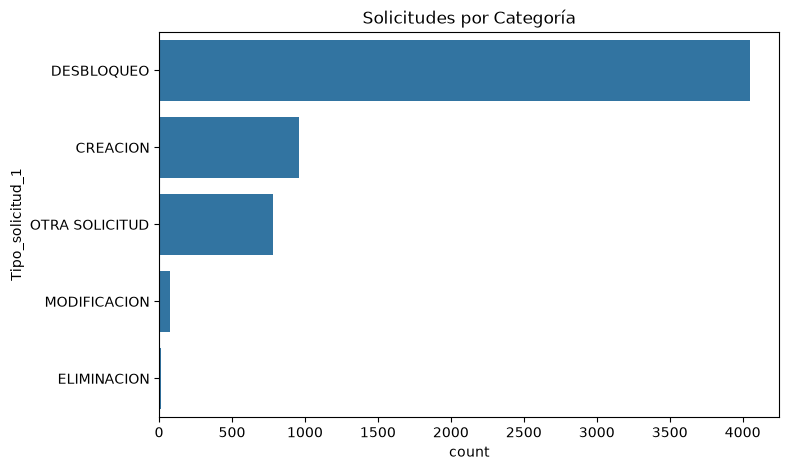

In [58]:
plt.figure(figsize=(8,5))
orden = df["Tipo_solicitud_1"].value_counts().index
sns.countplot(data=df,y="Tipo_solicitud_1",order=orden)
plt.title("Solicitudes por Categoría")
plt.show()

**Respuesta**: Como se puede observar en la gráfica, blablabla

**Conclusión**: Se observa que los meses con mayor venta promedio son los meses de vacaciones.
- apuntan a los _Insights_, un descubrimiento sobre los datos

### **Pregunta**: ¿Qué aplicativos generan más solicitudes?

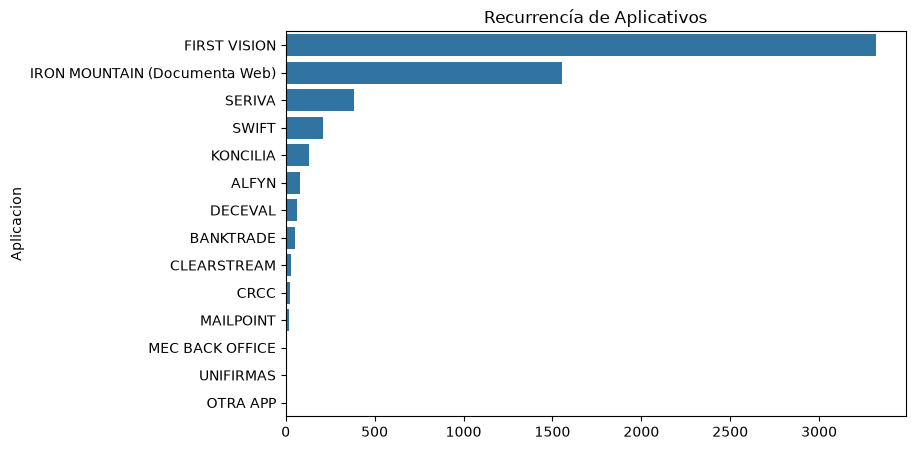

In [59]:
top = (df["Aplicacion"].value_counts().head(15))

plt.figure(figsize=(8,5))
sns.barplot(x=top.values,y=top.index)
plt.title("Recurrencía de Aplicativos")
plt.show()

### **Pregunta**: ¿Cómo se distribuyen los tiempos de atención?

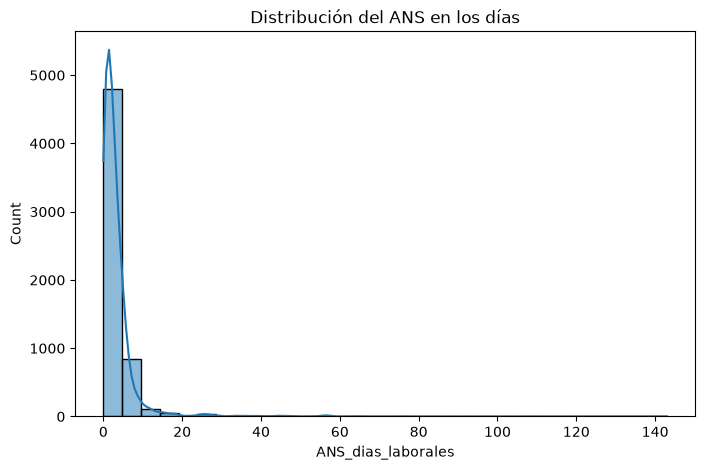

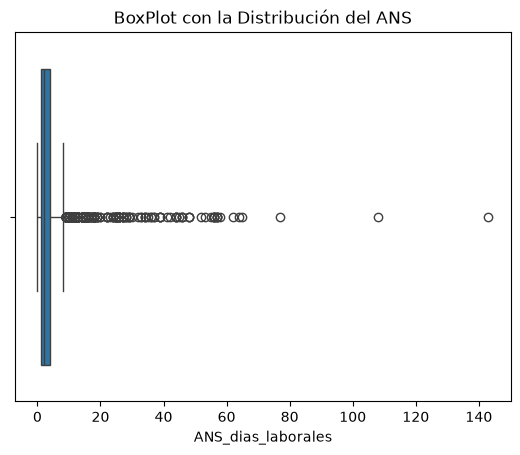

In [60]:
plt.figure(figsize=(8,5))
sns.histplot(df["ANS_dias_laborales"],bins=30,kde=True)
plt.title("Distribución del ANS en los días")
plt.show()

sns.boxplot(x=df["ANS_dias_laborales"])
plt.title("BoxPlot con la Distribución del ANS")
plt.show()

## 2. Análizando la Temporalidad

### **Pregunta**: ¿Cómo se distribuyen los tiempos de atención?

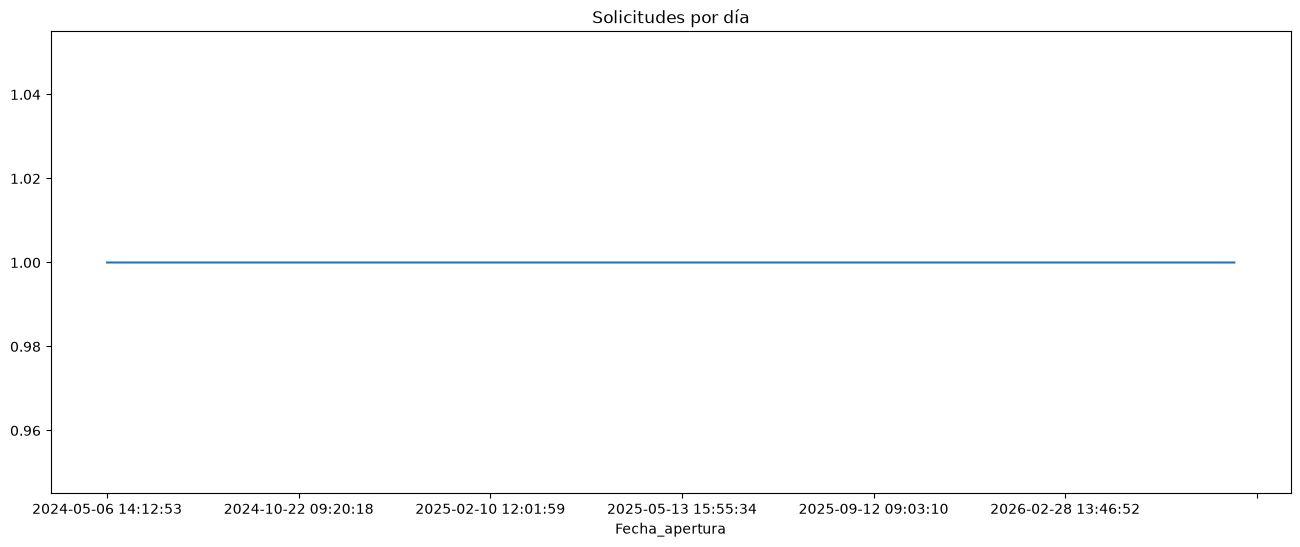

In [61]:
serie = (df.groupby("Fecha_apertura").size())
plt.figure(figsize=(16,6))
serie.plot()
plt.title("Solicitudes por día")
plt.show()

### **Pregunta**: ¿Cómo evolucionan estos tiempos por mes?

In [62]:
mensual = (df.groupby(pd.Grouper(key="Fecha_apertura",freq="M")).size())
plt.figure(figsize=(16,6))
mensual.plot()
plt.title("Solicitudes por mes")
plt.show()

ValueError: Invalid frequency: M. Failed to parse with error message: ValueError("'M' is no longer supported for offsets. Please use 'ME' instead.")

## 3. Observando el compartamiento en variables relacionadas

### **Pregunta**: ¿Existe relación entre el aplicativo y el tiempo de atención?

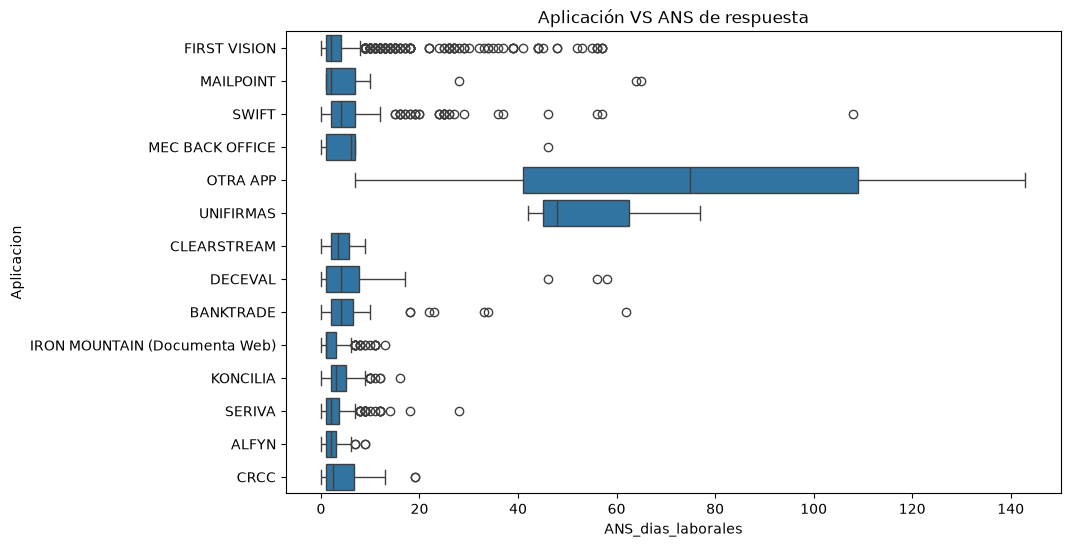

In [63]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="ANS_dias_laborales", y="Aplicacion")
plt.title("Aplicación VS ANS de respuesta")
plt.show()

## Análisis de Correlación

Identificar las columnas que tienen mayor impacto sobre mi modelo

In [64]:
matriz_corr = df.corr(numeric_only=True)

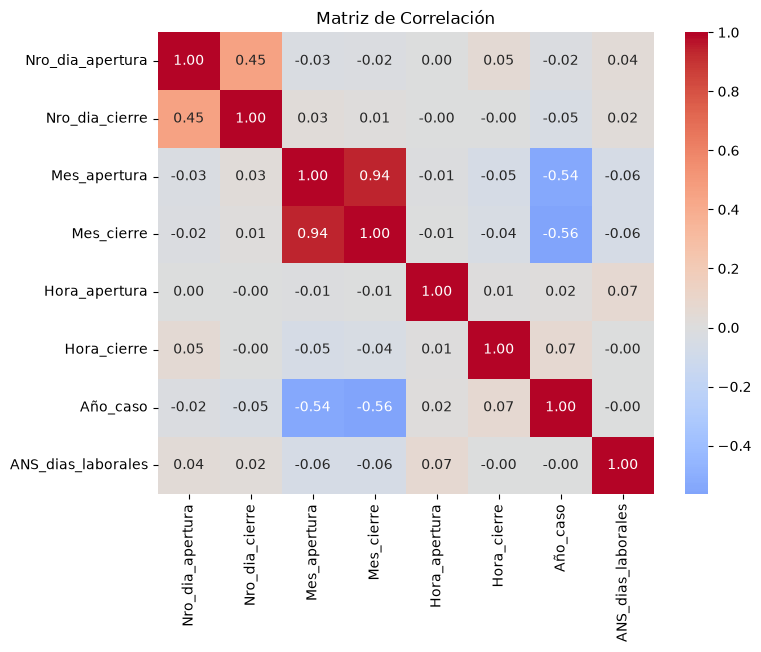

In [65]:
plt.figure(figsize=(8,6))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Matriz de Correlación")
plt.show()

**Último paso**: Guardar los datos ya analizados, organizados y listos para entrenar un modelo ML

In [17]:
df.to_csv(trusted_dir + 'datos_limpios_ml.csv', index=False)